In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Lifelines for Cox Baseline (Install via: pip install lifelines)
from lifelines import CoxPHFitter


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/data/tmp/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/data/tmp/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/data/tmp/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/data/tmp/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/d

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/data/tmp/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/data/tmp/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/data/tmp/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/data/tmp/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/d

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/data/tmp/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/data/tmp/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/data/tmp/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/data/tmp/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/d

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/data/tmp/opt/anaconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/data/tmp/opt/anaconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/data/tmp/opt/anaconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/data/tmp/opt/anaconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/d

AttributeError: _ARRAY_API not found

In [2]:
df = pd.read_excel('/data/users/quentin/final_package/experiments/survival_analysis/data/Melanoma_clinical_data_jack_may7.xlsx', '20211001_Melanoma_clinical_data')
for col in df.columns:
    if "cd8_phenotype_revised" in col:
        print(col)
        print(df[col].unique())
        
df = pd.read_csv('ord_longi.csv', index_col=0)

df["metastasis_location"] = df["metastasis_location"].apply(lambda x: ("lymph node" in x))
df["stage"] = pd.factorize(df["stage"])[0]
df["subtype"] = pd.factorize(df["subtype"])[0]
#print(list(df.columns))
columns2keep = ['age', 'sex', "brain_metastasis",  "tumor_mutational_burden", "immune_infiltration_status", "BRAFV600E_mutations", "metastasis_location", "stage", "subtype", 'fraction_WP1_NM_norm_long', 'resistant_WP1_NM_norm_long']#,'resistant_WP1_NM_norm','score_WP1_NM_norm_long','score_WP1_NM_norm','fraction_WP1_NM_norm_long','fraction_WP1_NM_norm']
columns2keep_FD = ['age', 'sex', "brain_metastasis",  "tumor_mutational_burden", "immune_infiltration_status", "BRAFV600E_mutations", "metastasis_location","stage", "subtype",   'score_FD_NM_norm_long']
columns2keep_FM = ['age', 'sex', "brain_metastasis",  "tumor_mutational_burden", "immune_infiltration_status", "BRAFV600E_mutations", "metastasis_location", "stage", "subtype", 'score_FM_NM_norm_long', 'resistant_FM_NM_norm_long']
columns2keep_baseline = ['age', 'sex', "brain_metastasis",  "tumor_mutational_burden", "immune_infiltration_status", "BRAFV600E_mutations", "metastasis_location"]

immuno_feat = "immunotherapies_tot_after_biopsy"
chemo_feat = "chemotherapies_tot_after_biopsy"
columns2keep.append(immuno_feat)
columns2keep_FD.append(immuno_feat)
columns2keep_FM.append(immuno_feat)
columns2keep_baseline.append(immuno_feat)


columns2keep.append(chemo_feat)
columns2keep_FD.append(chemo_feat)
columns2keep_FM.append(chemo_feat)
columns2keep_baseline.append(chemo_feat)

tuproIDs = df['tupro_id'].unique()
has_used_TD = {TID:False for TID in tuproIDs}
for itupro, tuproID in enumerate(tuproIDs):
    dffiltered = df.loc[df['tupro_id']==tuproID]
    if np.sum(dffiltered['targeted_tot_after_biopsy'])>1:
        has_used_TD[tuproID] = True
alldays = df['days'].unique()
states = df['state'].unique()
print(alldays, states)

cd8_phenotype_revised
[nan 'immune desert' 'immune excluded' 'inflamed'
 'inflamed / immune desert' 'immune excluded / inflamed'
 'immune desert / inflamed' 'inflamed / immune excluded']
[180 270 360 450 540 630 720 810] [3 2 5 6 1 4]


In [4]:
def convert_state(state):
    if state in [1,2]:
        return 1
    elif state in [3,4]:
        return 2
    elif state in [5]:
        return 3
    elif state in [6]:
        return 4
    else:
        assert False
        
def convert_state(state):
    if state in [1,2,3]:
        return 1
    elif state in [4,5,6]:
        return 0
    else:
        assert False
    
df['state'] = df['state'].apply(convert_state)
df['prev_state'] = df['prev_state'].apply(convert_state)

# Random Forest

Follow-up days evaluated: [np.int64(180), np.int64(270), np.int64(360), np.int64(450), np.int64(540), np.int64(630)]


Follow-up days: 100%|█████████████████████████████| 6/6 [01:04<00:00, 10.80s/it]



TIME-SPECIFIC ROC-AUC (95% patient-level bootstrap CI)
     Patients  Events (state=1)  Non-events (state=0)        scClone2DR          Baseline             scFPM         Clonal FM
Day                                                                                                                          
180        41                19                    22  0.49 (0.30-0.67)  0.39 (0.21-0.58)  0.48 (0.29-0.66)  0.49 (0.30-0.66)
270        36                15                    21  0.77 (0.60-0.91)  0.71 (0.52-0.87)  0.66 (0.46-0.84)  0.76 (0.59-0.90)
360        28                12                    16  0.61 (0.37-0.83)  0.47 (0.23-0.72)  0.49 (0.25-0.74)  0.66 (0.43-0.87)
450        22                11                    11  0.81 (0.60-0.99)  0.41 (0.17-0.68)  0.38 (0.15-0.64)  0.50 (0.23-0.77)
540        15                 8                     7  0.75 (0.44-1.00)  0.81 (0.53-1.00)  0.77 (0.46-1.00)  0.75 (0.45-1.00)
630         7                 4                     3  0.75 (0

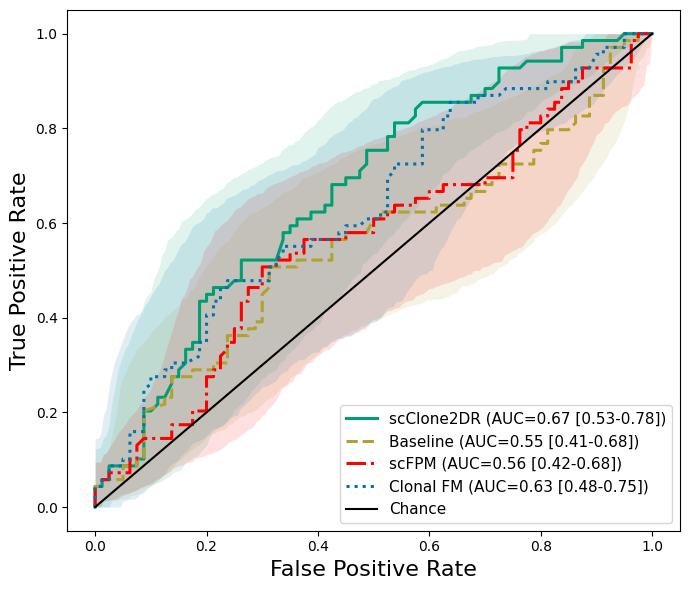

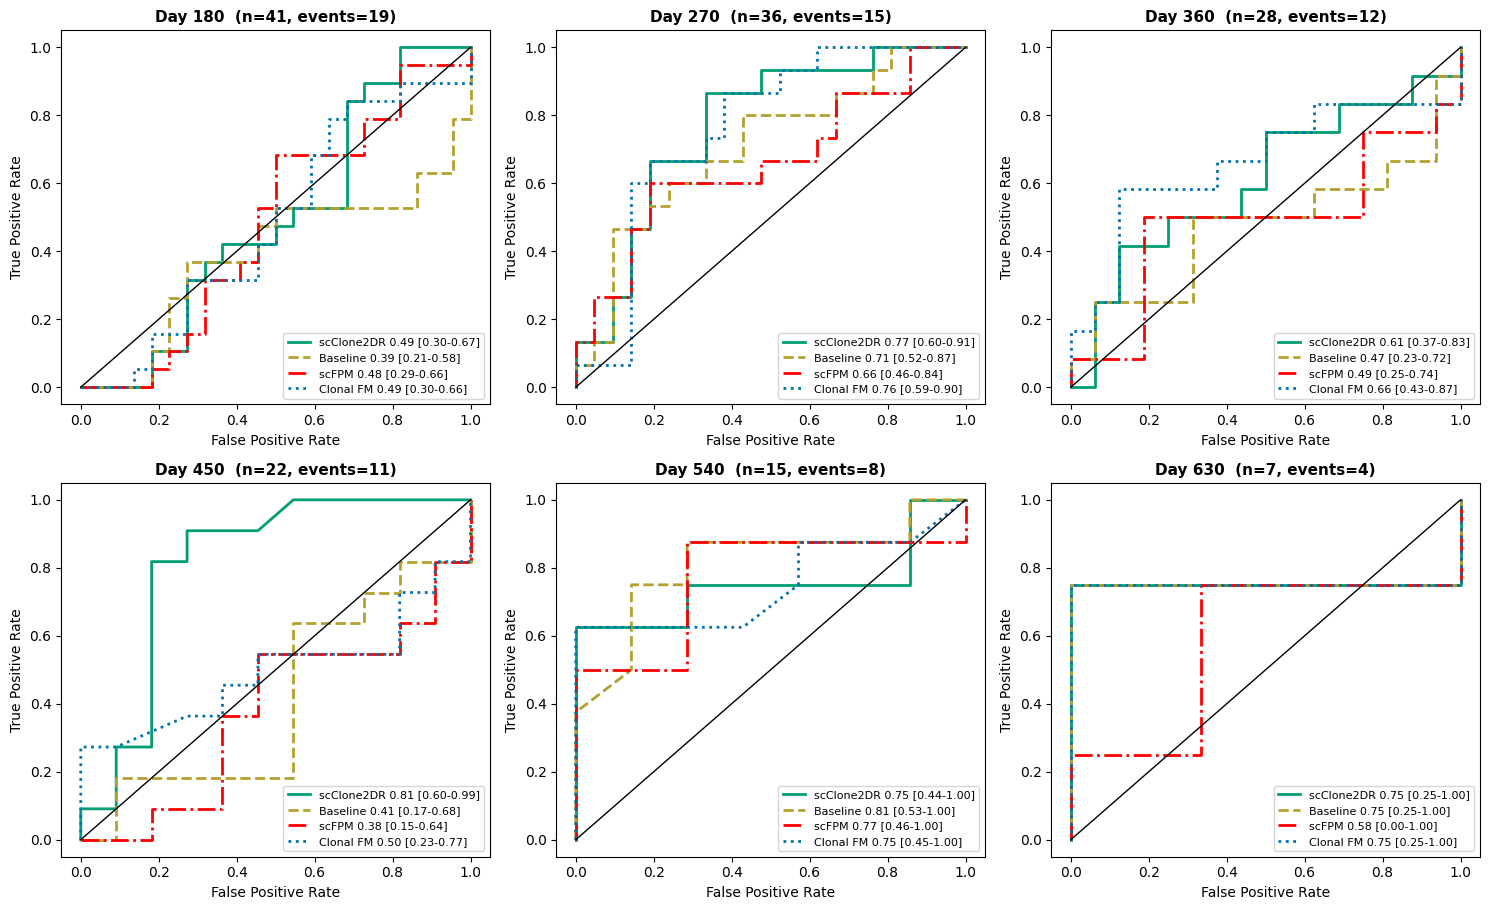

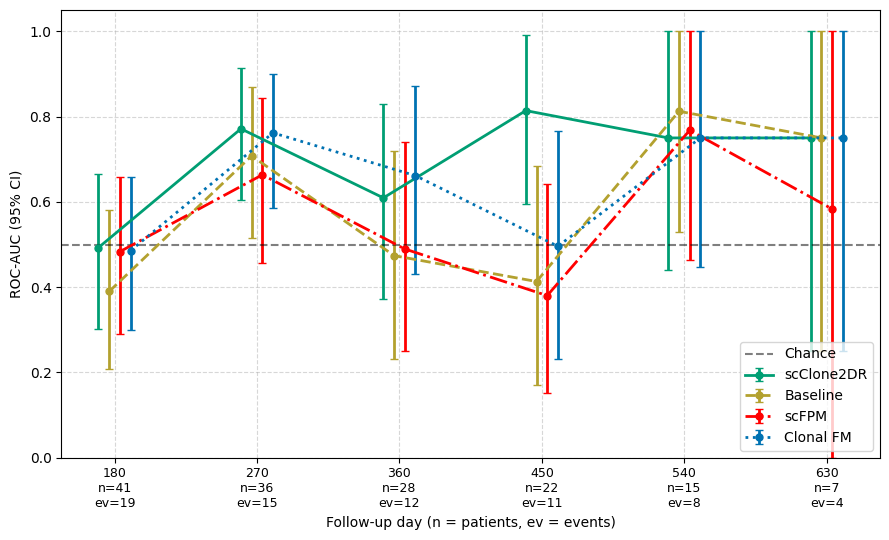

In [25]:
"""
Time-specific and pooled ROC/AUC evaluation with patient-level bootstrap CIs.

Expects these objects to already exist (as in your notebook):
    df                      DataFrame with columns 'tupro_id', 'days', 'state' + feature columns
    alldays                 array of follow-up days
    columns2keep, columns2keep_baseline, columns2keep_FD, columns2keep_FM

Outputs:
    - Table per follow-up time: number of patients, events, non-events, AUC (95% CI) per model
    - Pooled AUC (95% CI) using a patient-level (cluster) bootstrap
    - Figures: pooled ROC with CI bands, per-time ROC panels, AUC trajectory with CIs
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# ---------------------------------------------------------------------
# Settings
# ---------------------------------------------------------------------
N_BOOT = 2000        # bootstrap replicates
SEED = 0             # same seed for all models -> paired resamples
ALPHA = 0.05         # 95% CI
OUT_DIR = "/data/users/quentin/package_paper/experiments/survival_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

feature_sets = {
    "ours": columns2keep,
    "baseline": columns2keep_baseline,
    "FD": columns2keep_FD,
    "FM": columns2keep_FM,
}
name2label = {"ours": "scClone2DR", "baseline": "Baseline",
              "FD": "scFPM", "FM": "Clonal FM"}
styles = {"ours": ("#009E73", "-"), "baseline": ("#B3A12F", "--"),
          "FD": ("red", "-."), "FM": ("#0072B2", ":")}
FPR_GRID = np.linspace(0, 1, 201)


# =====================================================================
# 1. LEAVE-ONE-PATIENT-OUT PREDICTIONS AT EACH FOLLOW-UP TIME
# =====================================================================
valid_days = [d for d in alldays if (df["days"] == d).sum() > 2]
print("Follow-up days evaluated:", valid_days)

records = []
for day in tqdm(valid_days, desc="Follow-up days"):
    d = df[df["days"] == day].reset_index(drop=True)
    y = d["state"].astype(int).to_numpy()
    pids = d["tupro_id"].to_numpy()
    Xs = {m: d[cols].to_numpy() for m, cols in feature_sets.items()}

    for pid in np.unique(pids):
        test = pids == pid          # all rows of this patient at this time
        train = ~test
        for method, X in Xs.items():
            if np.unique(y[train]).size < 2:
                # Training set has a single class: no valid model for this fold
                probs = np.full(test.sum(), np.nan)
            else:
                clf = RandomForestClassifier(max_depth=6, random_state=SEED)
                clf.fit(X[train], y[train])
                probs = clf.predict_proba(X[test])[:, 1]
            for yi, pi in zip(y[test], probs):
                records.append({"method": method, "tupro_id": pid, "days": day,
                                "y_true": int(yi), "prob": pi})

df_pred = pd.DataFrame(records)
n_failed = df_pred["prob"].isna().sum()
if n_failed:
    print(f"Warning: {n_failed} predictions missing (single-class training folds).")


# =====================================================================
# 2. HELPERS: PATIENT-LEVEL BOOTSTRAP AND COUNTS
# =====================================================================
def patient_bootstrap_roc(y, s, pids, n_boot=N_BOOT, seed=SEED, alpha=ALPHA):
    """
    AUC and ROC curve with percentile CIs from a patient-level (cluster) bootstrap:
    patients are resampled with replacement, keeping all their observations together.
    Using the same seed for every model gives paired resamples across models.
    """
    y, s, pids = np.asarray(y), np.asarray(s), np.asarray(pids)
    out = dict(auc=np.nan, auc_lo=np.nan, auc_hi=np.nan, fpr=None, tpr=None,
               tpr_lo=None, tpr_hi=None, n_boot_valid=0)
    if np.unique(y).size < 2:
        return out  # AUC undefined with a single outcome class

    out["auc"] = roc_auc_score(y, s)
    out["fpr"], out["tpr"], _ = roc_curve(y, s)

    groups = [np.flatnonzero(pids == p) for p in np.unique(pids)]
    rng = np.random.default_rng(seed)
    aucs, tprs = [], []
    for _ in range(n_boot):
        pick = rng.integers(0, len(groups), len(groups))
        idx = np.concatenate([groups[k] for k in pick])
        yb, sb = y[idx], s[idx]
        if np.unique(yb).size < 2:
            continue
        aucs.append(roc_auc_score(yb, sb))
        f, t, _ = roc_curve(yb, sb)
        tprs.append(np.interp(FPR_GRID, f, t))

    q = [100 * alpha / 2, 100 * (1 - alpha / 2)]
    out["auc_lo"], out["auc_hi"] = np.percentile(aucs, q)
    out["tpr_lo"], out["tpr_hi"] = np.percentile(tprs, q, axis=0)
    out["n_boot_valid"] = len(aucs)
    return out


def cohort_counts(sub):
    """Number of patients, observations and outcomes contributing to an analysis."""
    per_patient = sub.groupby("tupro_id")["y_true"].max()
    return {
        "Patients": sub["tupro_id"].nunique(),
        "Observations": len(sub),
        "Events (state=1)": int(sub["y_true"].sum()),
        "Non-events (state=0)": int((sub["y_true"] == 0).sum()),
        "Patients with >=1 event": int(per_patient.sum()),
    }


def fmt_auc(auc, lo, hi):
    return "n/a (one class)" if np.isnan(auc) else f"{auc:.2f} ({lo:.2f}-{hi:.2f})"


# =====================================================================
# 3. TIME-SPECIFIC AUCs WITH 95% CI AND COUNTS
# =====================================================================
rows, roc_by_day = [], {}
for day in valid_days:
    for method in feature_sets:
        sub_all = df_pred[(df_pred["days"] == day) & (df_pred["method"] == method)]
        sub = sub_all.dropna(subset=["prob"])
        res = patient_bootstrap_roc(sub["y_true"], sub["prob"], sub["tupro_id"])
        roc_by_day[(day, method)] = res
        # Counts use everyone observed at this time point, even if no prediction was possible
        rows.append({"Day": day, "Method": method, **cohort_counts(sub_all),
                     "AUC": res["auc"], "CI_low": res["auc_lo"], "CI_high": res["auc_hi"]})

df_time = pd.DataFrame(rows)
df_time["AUC (95% CI)"] = [fmt_auc(a, l, h) for a, l, h in
                           zip(df_time["AUC"], df_time["CI_low"], df_time["CI_high"])]

count_cols = ["Patients", "Events (state=1)", "Non-events (state=0)"]
counts = df_time[df_time["Method"] == "ours"].set_index("Day")[count_cols]
auc_table = (df_time.pivot(index="Day", columns="Method", values="AUC (95% CI)")
             [list(feature_sets)].rename(columns=name2label))
summary_time = counts.join(auc_table)

print("\n" + "=" * 90)
print("TIME-SPECIFIC ROC-AUC (95% patient-level bootstrap CI)")
print("=" * 90)
print(summary_time.to_string())
summary_time.to_csv(os.path.join(OUT_DIR, "auc_time_specific.csv"))
df_time.to_csv(os.path.join(OUT_DIR, "auc_time_specific_long.csv"), index=False)


# =====================================================================
# 4. POOLED ANALYSIS ACROSS TIME POINTS (PATIENT-LEVEL BOOTSTRAP)
# =====================================================================
pooled, pooled_rows = {}, []
for method in feature_sets:
    sub = df_pred[df_pred["method"] == method].dropna(subset=["prob"])
    res = patient_bootstrap_roc(sub["y_true"], sub["prob"], sub["tupro_id"])
    pooled[method] = res
    pooled_rows.append({"Method": name2label[method], **cohort_counts(sub),
                        "AUC (95% CI)": fmt_auc(res["auc"], res["auc_lo"], res["auc_hi"])})

summary_pooled = pd.DataFrame(pooled_rows).set_index("Method")
print("\n" + "=" * 90)
print("POOLED ROC-AUC ACROSS FOLLOW-UP TIMES (95% CI, patients resampled as clusters)")
print("=" * 90)
print(summary_pooled.to_string())
summary_pooled.to_csv(os.path.join(OUT_DIR, "auc_pooled.csv"))


# =====================================================================
# 5. FIGURE: POOLED ROC CURVES WITH 95% CI BANDS
# =====================================================================
plt.figure(figsize=(7, 6))
for method in feature_sets:
    res = pooled[method]
    if np.isnan(res["auc"]):
        continue
    color, ls = styles[method]
    plt.plot(res["fpr"], res["tpr"], color=color, linestyle=ls, linewidth=2.2,
             label=f"{name2label[method]} (AUC={res['auc']:.2f} [{res['auc_lo']:.2f}-{res['auc_hi']:.2f}])")
    plt.fill_between(FPR_GRID, res["tpr_lo"], res["tpr_hi"], color=color, alpha=0.12, linewidth=0)

plt.plot([0, 1], [0, 1], label="Chance", color="black")
plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)
plt.legend(fontsize=11, loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "ROCs_pooled_CI.png"), dpi=200)
plt.show()


# =====================================================================
# 6. FIGURE: ROC CURVES AT EACH FOLLOW-UP TIME
# =====================================================================
plot_days = [d for d in valid_days if not np.isnan(roc_by_day[(d, "ours")]["auc"])]
if plot_days:
    ncols = min(3, len(plot_days))
    nrows = int(np.ceil(len(plot_days) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.6 * nrows), squeeze=False)
    axes = axes.flatten()
    for ax, day in zip(axes, plot_days):
        for method in feature_sets:
            res = roc_by_day[(day, method)]
            if np.isnan(res["auc"]):
                continue
            color, ls = styles[method]
            ax.plot(res["fpr"], res["tpr"], color=color, linestyle=ls, linewidth=2,
                    label=f"{name2label[method]} {res['auc']:.2f} [{res['auc_lo']:.2f}-{res['auc_hi']:.2f}]")
        ax.plot([0, 1], [0, 1], color="black", linewidth=1)
        c = counts.loc[day]
        ax.set_title(f"Day {day}  (n={c['Patients']}, events={c['Events (state=1)']})",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(fontsize=8, loc="lower right")
    for ax in axes[len(plot_days):]:
        fig.delaxes(ax)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "ROCs_per_timepoint.png"), dpi=200)
    plt.show()


# =====================================================================
# 7. FIGURE: TIME-SPECIFIC AUC TRAJECTORY WITH 95% CI
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 5.5))
methods = list(feature_sets)
step = 0.015 * (max(valid_days) - min(valid_days) or 1)   # small x-offset per model
for i, method in enumerate(methods):
    d = df_time[df_time["Method"] == method].dropna(subset=["AUC"])
    x = d["Day"] + (i - (len(methods) - 1) / 2) * step
    color, ls = styles[method]
    ax.errorbar(x, d["AUC"], yerr=[d["AUC"] - d["CI_low"], d["CI_high"] - d["AUC"]],
                fmt="o", linestyle=ls, color=color, linewidth=2, capsize=3,
                markersize=5, label=name2label[method])
ax.axhline(0.5, color="black", linestyle="--", alpha=0.5, label="Chance")

# Number of patients / events under each time point
ax.set_xticks(valid_days)
ax.set_xticklabels([f"{d}\nn={counts.loc[d, 'Patients']}\nev={counts.loc[d, 'Events (state=1)']}"
                    for d in valid_days], fontsize=9)
ax.set_xlabel("Follow-up day (n = patients, ev = events)")
ax.set_ylabel("ROC-AUC (95% CI)")
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "AUC_trajectory_CI.png"), dpi=200)
plt.show()

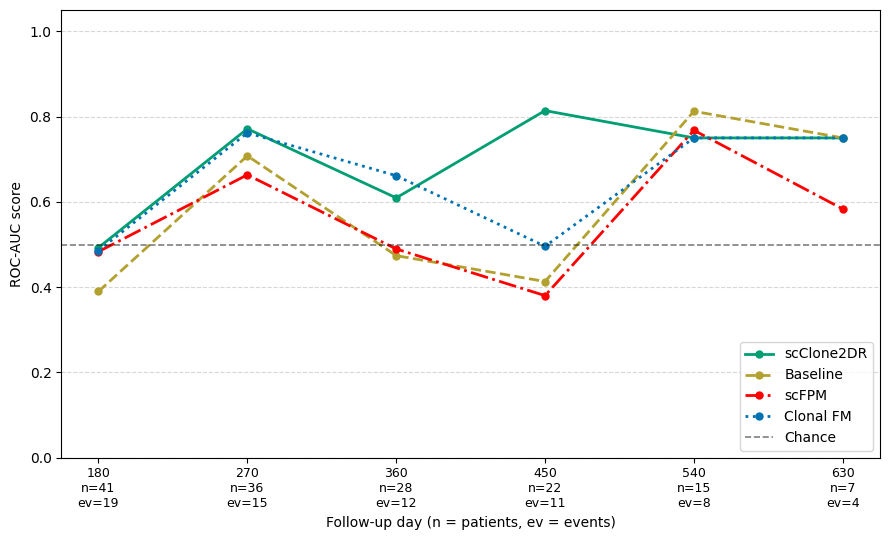

In [31]:
# =====================================================================
# 7. FIGURE: TIME-SPECIFIC AUC TRAJECTORY
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 5.5))

methods = list(feature_sets)
step = 0.015 * (max(valid_days) - min(valid_days) or 1)

for i, method in enumerate(methods):
    d = (
        df_time[df_time["Method"] == method]
        .dropna(subset=["AUC"])
        .sort_values("Day")
    )

    # Small horizontal offset to separate methods at the same day
    x = d["Day"] #+ (i - (len(methods) - 1) / 2) * step

    color, ls = styles[method]

    ax.plot(
        x,
        d["AUC"],
        marker="o",
        linestyle=ls,
        color=color,
        linewidth=2,
        markersize=5,
        label=name2label[method]
    )

# Chance level
ax.axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.5,
    label="Chance"
)

# Number of patients / events under each time point
ax.set_xticks(valid_days)
ax.set_xticklabels(
    [
        f"{d}\n"
        f"n={counts.loc[d, 'Patients']}\n"
        f"ev={counts.loc[d, 'Events (state=1)']}"
        for d in valid_days
    ],
    fontsize=9
)

ax.set_xlabel("Follow-up day (n = patients, ev = events)")
ax.set_ylabel("ROC-AUC score")
ax.set_ylim(0, 1.05)

ax.grid(True, axis="y", linestyle="--", alpha=0.5)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "AUC_trajectory.png"),
    dpi=200,
    bbox_inches="tight"
)
plt.show()

# Cox Regression

Running Global Time-Varying Cox Model across all patient histories...

GLOBAL TIME-VARYING COX MODEL PERFORMANCE COMPARISON

--- ROC-AUC Across Follow-Up Days ---
Method  Clonal FM  baseline  scClone2DR     scFPM
Day                                              
180      0.550239  0.411483    0.619617  0.492823
270      0.726984  0.574603    0.774603  0.676190
360      0.765625  0.562500    0.807292  0.734375
450      0.628099  0.462810    0.793388  0.570248
540      0.785714  0.696429    0.839286  0.678571
630      0.833333  0.500000    0.916667  0.750000
720           NaN       NaN         NaN       NaN
810           NaN       NaN         NaN       NaN

--- Accuracy Across Follow-Up Days ---
Method  Clonal FM  baseline  scClone2DR     scFPM
Day                                              
180      0.536585  0.512195    0.560976  0.536585
270      0.638889  0.611111    0.694444  0.694444
360      0.642857  0.571429    0.678571  0.678571
450      0.590909  0.500000    0.681818  0.5909

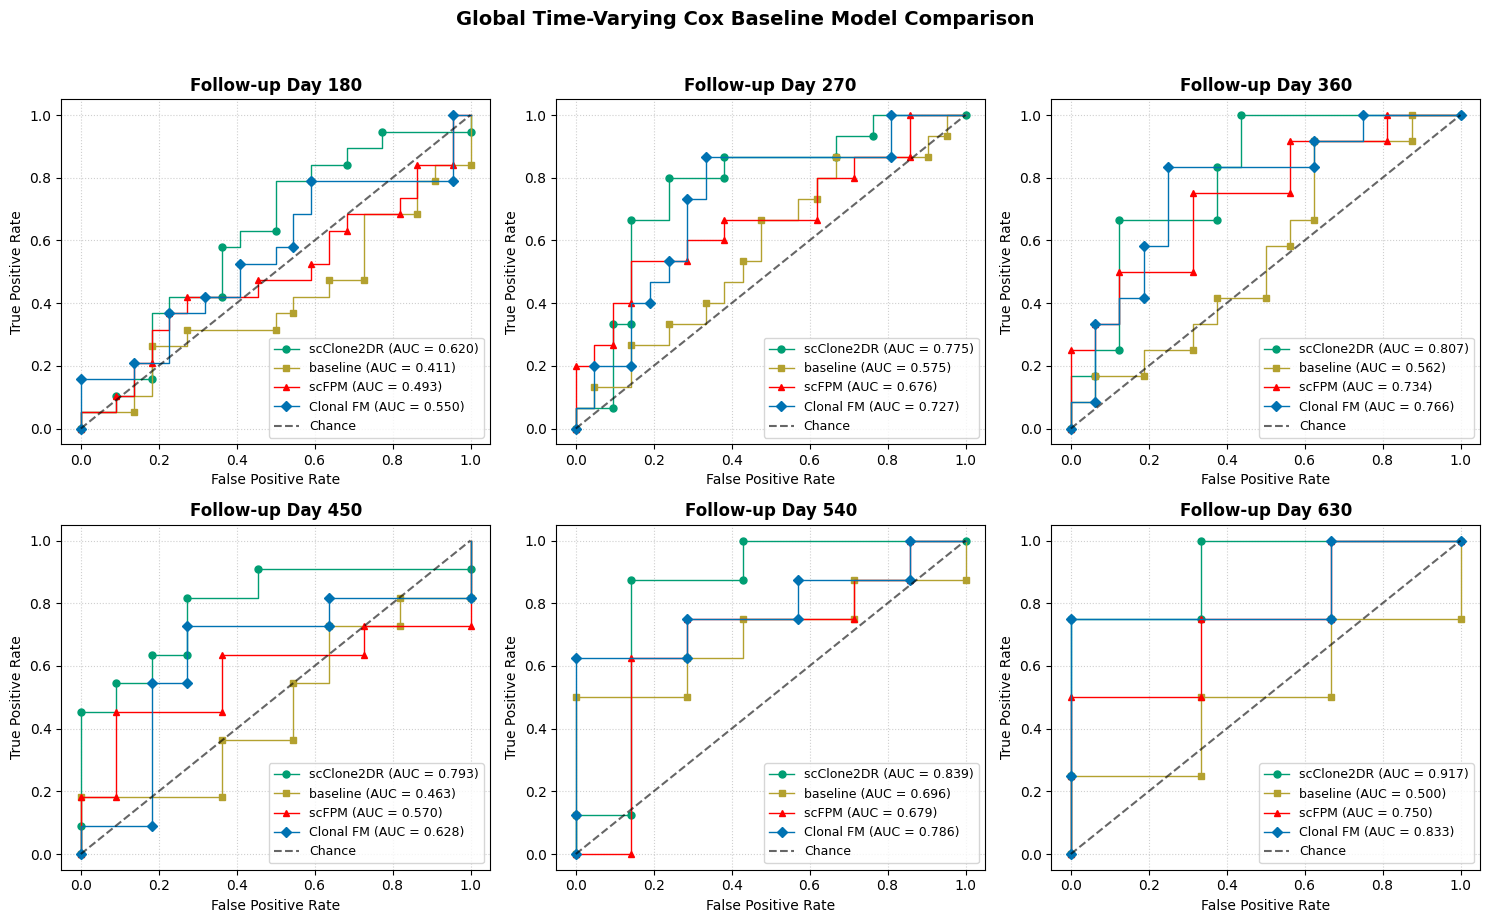

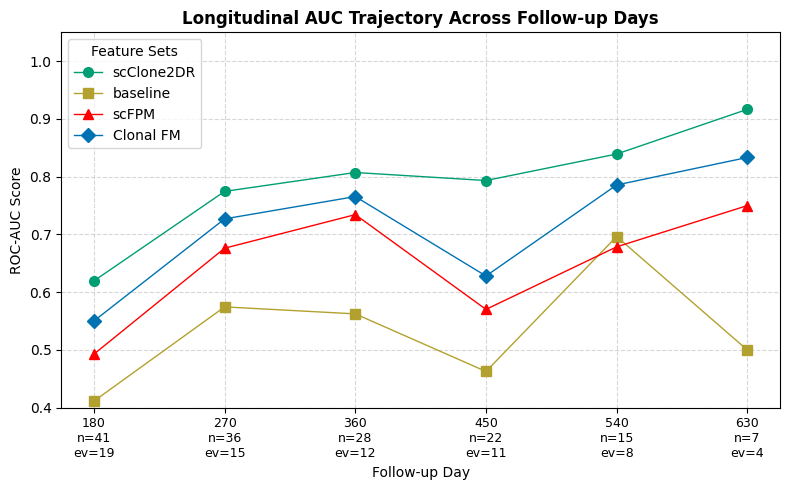

In [37]:
import numpy as np
import pandas as pd
from lifelines import CoxTimeVaryingFitter
from sklearn.metrics import roc_auc_score, accuracy_score

# =====================================================================
# 1. HELPER: PREPARE COUNTING PROCESS (START, STOP) DATASET
# =====================================================================

def build_counting_process_df(df, feature_cols, id_col='tupro_id', time_col='days', event_col='state'):
    """
    Transforms long-format longitudinal data into (start, stop] interval format
    suitable for time-varying Cox regression.
    """
    df_sorted = df.sort_values(by=[id_col, time_col]).copy()
    
    # Calculate start time as the previous stop time per patient
    df_sorted['start_day'] = df_sorted.groupby(id_col)[time_col].shift(1).fillna(0)
    df_sorted['stop_day'] = df_sorted[time_col]
    
    # Ensure start < stop to prevent zero-length intervals
    df_sorted = df_sorted[df_sorted['stop_day'] > df_sorted['start_day']]
    
    cols_to_keep = [id_col, 'start_day', 'stop_day', event_col] + feature_cols
    return df_sorted[cols_to_keep].reset_index(drop=True)


# =====================================================================
# 2. TIME-VARYING COX BASELINE WRAPPER
# =====================================================================

class GlobalTimeVaryingCoxBaseline:
    """
    Fits a single Cox model across ALL longitudinal patient history simultaneously.
    """
    def __init__(self, penalizer=0.1):
        self.ctvf = CoxTimeVaryingFitter(penalizer=penalizer)
        self.feature_cols = None
        
    def fit(self, df_train, feature_cols, id_col='tupro_id', event_col='state'):
        self.feature_cols = feature_cols
        
        # Prepare start-stop dataset
        df_cp = build_counting_process_df(df_train, feature_cols, id_col=id_col, event_col=event_col)
        
        # Fit global time-varying Cox model
        self.ctvf.fit(
            df_cp,
            id_col=id_col,
            start_col='start_day',
            stop_col='stop_day',
            event_col=event_col,
            robust=False, # Adjusts variance for repeated intra-patient observations
            show_progress=False
        )

    def predict_risk(self, df_test):
        return self.ctvf.predict_log_partial_hazard(df_test[self.feature_cols]).values
    
    def predict_risk_old(self, df_test):
        """
        Predicts relative hazard/risk scores for test interval instances.
        """
        # Partial hazard matrix calculation
        X_test = df_test[self.feature_cols]
        # Multiply design matrix by fitted Cox coefficients
        log_hazards = np.dot(X_test.values, self.ctvf.params_.values)
        # Convert to probability proxy using sigmoid transformation
        risk_probs = 1 / (1 + np.exp(-log_hazards))
        return risk_probs


# =====================================================================
# 3. LEAVE-ONE-GROUP-OUT CROSS VALIDATION WITH GLOBAL COX MODEL
# =====================================================================

unique_patients = df['tupro_id'].unique()
cox_predictions = []

print("Running Global Time-Varying Cox Model across all patient histories...")

# Define feature sets
feature_sets = {
    "scClone2DR": columns2keep,
    "baseline": columns2keep_baseline,
    "scFPM": columns2keep_FD,
    "Clonal FM": columns2keep_FM
}
for method, cols2keep in feature_sets.items():
    for test_patient in unique_patients:
        # Train / Test split by Patient ID
        train_df = df[df['tupro_id'] != test_patient].reset_index(drop=True)
        test_df = df[df['tupro_id'] == test_patient].reset_index(drop=True)

        if len(test_df) == 0:
            continue

        # Fit ONE global Cox model on ALL historical data of train patients
        global_cox = GlobalTimeVaryingCoxBaseline(penalizer=0.1)
        try:
            global_cox.fit(train_df, feature_cols=cols2keep, id_col='tupro_id', event_col='state')
            probs = global_cox.predict_risk(test_df)
        except Exception as e:
            # Fallback if convergence fails on small sample fold
            probs = np.full(len(test_df), 0.5)

        for idx, row in test_df.iterrows():
            cox_predictions.append({
                'method': method,
                'tupro_id': test_patient,
                'days': row['days'],
                'y_true': row['state'],
                'prob_Cox_Global': probs[idx]
            })

# Construct complete dataframe after evaluating all feature sets
df_cox_results = pd.DataFrame(cox_predictions)


# =====================================================================
# 4. COMPUTE METRICS & DISPLAY SUMMARY TABLE
# =====================================================================

print("\n" + "="*70)
print("GLOBAL TIME-VARYING COX MODEL PERFORMANCE COMPARISON")
print("="*70)

metrics_list = []
valid_days = sorted(df_cox_results['days'].unique())

for day in valid_days:
    for method in feature_sets.keys():
        sub = df_cox_results[(df_cox_results['days'] == day) & (df_cox_results['method'] == method)]
        
        # Check if fold slice has both positive and negative classes for ROC calculation
        if len(sub['y_true'].unique()) < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(sub['y_true'], sub['prob_Cox_Global'])
            
        acc = accuracy_score(sub['y_true'], (sub['prob_Cox_Global'] >= 0.5).astype(int))
        
        metrics_list.append({
            'Day': day,
            'Method': method,
            'Samples': len(sub),
            'Accuracy': acc,
            'ROC_AUC': auc
        })

df_metrics = pd.DataFrame(metrics_list)

# Pivot table for clean side-by-side metric inspection
auc_pivot = df_metrics.pivot(index='Day', columns='Method', values='ROC_AUC')
acc_pivot = df_metrics.pivot(index='Day', columns='Method', values='Accuracy')

print("\n--- ROC-AUC Across Follow-Up Days ---")
print(auc_pivot.to_string())

print("\n--- Accuracy Across Follow-Up Days ---")
print(acc_pivot.to_string())


# =====================================================================
# 5. MULTI-PANEL ROC CURVE COMPARISON PLOTS
# =====================================================================

# Filter days that have enough class variance for ROC plotting
plottable_days = [
    day for day in valid_days
    if df_cox_results[df_cox_results['days'] == day]['y_true'].nunique() > 1
]

n_days = len(plottable_days)
cols = min(3, n_days)
rows = int(np.ceil(n_days / cols))

fig, axes = plt.subplots(
    rows, cols,
    figsize=(5 * cols, 4.5 * rows),
    squeeze=False
)
axes = axes.flatten()

colors = {
    'scClone2DR': '#009E73',
    'baseline': '#B3A12F',
    'scFPM': 'red',
    'Clonal FM': '#0072B2'
}

# Different marker for each method
markers = {
    'scClone2DR': 'o',
    'baseline': 's',
    'scFPM': '^',
    'Clonal FM': 'D'
}

for idx, day in enumerate(plottable_days):
    ax = axes[idx]

    for method in feature_sets.keys():
        sub = df_cox_results[
            (df_cox_results['days'] == day) &
            (df_cox_results['method'] == method)
        ]

        y_true = sub['y_true'].values
        y_prob = sub['prob_Cox_Global'].values

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = roc_auc_score(y_true, y_prob)

        ax.plot(
            fpr,
            tpr,
            label=f"{method} (AUC = {auc_val:.3f})",
            color=colors.get(method),
            marker=markers.get(method),       # <-- different marker
            markevery=0.12,                   # <-- avoid too many markers
            markersize=5,
            linewidth=1
        )

    ax.plot(
        [0, 1],
        [0, 1],
        'k--',
        alpha=0.6,
        label='Chance'
    )

    ax.set_title(
        f"Follow-up Day {day}",
        fontsize=12,
        fontweight='bold'
    )
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Global Time-Varying Cox Baseline Model Comparison",
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()


# =====================================================================
# 6. LONGITUDINAL AUC TRAJECTORY PLOT
# =====================================================================

plt.figure(figsize=(8, 5))

for method in feature_sets.keys():
    sub_metrics = df_metrics[df_metrics['Method'] == method]

    plt.plot(
        sub_metrics['Day'],
        sub_metrics['ROC_AUC'],
        marker=markers.get(method),       # <-- different marker
        color=colors.get(method),
        linewidth=1,
        markersize=7,
        label=method
    )

plt.title(
    "Longitudinal AUC Trajectory Across Follow-up Days",
    fontsize=12,
    fontweight='bold'
)

counts = df_metrics[
    df_metrics["Method"] == "scClone2DR"
].set_index("Day")

counts['Events (state=1)'] = np.zeros(
    counts.shape[0],
    dtype=int
)

for day in valid_days:
    nevents = df_cox_results[
        (df_cox_results["method"] == "scClone2DR") &
        (df_cox_results["days"] == day)
    ]['y_true'].sum()

    counts.loc[day, 'Events (state=1)'] = int(nevents)

counts = counts[
    counts['Events (state=1)'] > 0
]

valid_days = list(counts.index)

ax = plt.gca()

ax.set_xticks(valid_days)
ax.set_xticklabels(
    [
        f"{d}\n"
        f"n={counts.loc[d, 'Samples']}\n"
        f"ev={counts.loc[d, 'Events (state=1)']}"
        for d in valid_days
    ],
    fontsize=9
)

plt.xlabel("Follow-up Day")
plt.ylabel("ROC-AUC Score")
plt.ylim(0.4, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Feature Sets", loc="upper left")
plt.tight_layout()

plt.savefig(
    'cox_longitudinal.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()

In [27]:
counts

,Method,Samples,Accuracy,ROC_AUC,Events (state=1)
Day,,,,,
180,ours,41,0.560976,0.619617,19
270,ours,36,0.694444,0.774603,15
360,ours,28,0.678571,0.807292,12
450,ours,22,0.681818,0.793388,11
540,ours,15,0.733333,0.839286,8
630,ours,7,0.857143,0.916667,4
720,ours,2,0.500000,NaN,0
810,ours,1,0.000000,NaN,0


In [20]:
from itertools import combinations
from sklearn.metrics import roc_auc_score
from statsmodels.stats.multitest import multipletests

def paired_cluster_bootstrap_auc(df_res, m1, m2, day=None, n_boot=2000, seed=0,
                                 score_col='prob_Cox_Global'):
    d = df_res if day is None else df_res[df_res['days'] == day]
    d = d.dropna(subset=[score_col])

    # One row per (patient, day), one column per method
    wide = d.pivot_table(index=['tupro_id', 'days'], columns='method', values=score_col)
    y = (d.drop_duplicates(['tupro_id', 'days'])
           .set_index(['tupro_id', 'days'])['y_true']
           .loc[wide.index].values)
    s1, s2 = wide[m1].values, wide[m2].values

    obs = roc_auc_score(y, s1) - roc_auc_score(y, s2)

    # Resample whole patients to respect repeated measures
    pids = wide.index.get_level_values('tupro_id').values
    groups = {p: np.where(pids == p)[0] for p in np.unique(pids)}
    keys = list(groups)
    rng = np.random.default_rng(seed)

    diffs = []
    for _ in range(n_boot):
        idx = np.concatenate([groups[p] for p in rng.choice(keys, len(keys), replace=True)])
        if len(np.unique(y[idx])) < 2:
            continue
        diffs.append(roc_auc_score(y[idx], s1[idx]) - roc_auc_score(y[idx], s2[idx]))
    diffs = np.array(diffs)

    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    return obs, ci_low, ci_high, p


# Pairwise comparisons, pooled across days
rows = []
for m1, m2 in combinations(feature_sets.keys(), 2):
    diff, lo, hi, p = paired_cluster_bootstrap_auc(df_cox_results, m1, m2)
    rows.append({'Comparison': f'{m1} vs {m2}', 'dAUC': diff,
                 'CI_low': lo, 'CI_high': hi, 'p': p})

df_tests = pd.DataFrame(rows)
df_tests['p_holm'] = multipletests(df_tests['p'], method='holm')[1]
print(df_tests.round(3).to_string(index=False))

      Comparison   dAUC  CI_low  CI_high     p  p_holm
ours vs baseline  0.226   0.101    0.361 0.000   0.000
      ours vs FD  0.124   0.041    0.219 0.002   0.010
      ours vs FM  0.066  -0.011    0.154 0.112   0.224
  baseline vs FD -0.103  -0.209    0.000 0.055   0.165
  baseline vs FM -0.161  -0.287   -0.027 0.014   0.056
        FD vs FM -0.058  -0.152    0.038 0.235   0.235


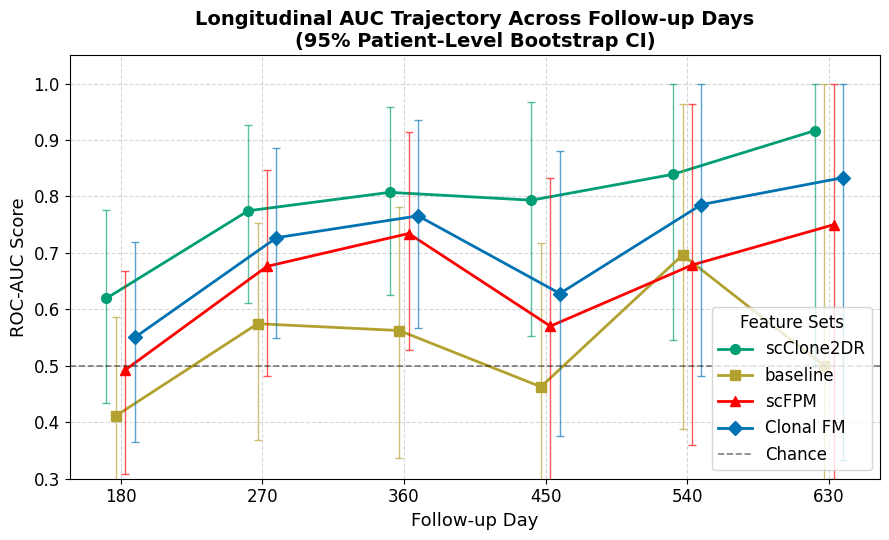

    Method  Day   AUC  CI_low  CI_high  Samples
scClone2DR  180 0.620   0.434    0.776       41
scClone2DR  270 0.775   0.612    0.927       36
scClone2DR  360 0.807   0.625    0.959       28
scClone2DR  450 0.793   0.553    0.967       22
scClone2DR  540 0.839   0.545    1.000       15
scClone2DR  630 0.917   0.500    1.000        7
  baseline  180 0.411   0.239    0.587       41
  baseline  270 0.575   0.368    0.753       36
  baseline  360 0.562   0.337    0.781       28
  baseline  450 0.463   0.214    0.718       22
  baseline  540 0.696   0.389    0.963       15
  baseline  630 0.500   0.000    1.000        7
     scFPM  180 0.493   0.309    0.667       41
     scFPM  270 0.676   0.482    0.847       36
     scFPM  360 0.734   0.528    0.914       28
     scFPM  450 0.570   0.298    0.833       22
     scFPM  540 0.679   0.360    0.964       15
     scFPM  630 0.750   0.300    1.000        7
 Clonal FM  180 0.550   0.365    0.720       41
 Clonal FM  270 0.727   0.548    0.886  

In [59]:
import matplotlib.pyplot as plt

# =====================================================================
# FONT SIZES
# =====================================================================

TITLE_SIZE = 14
LABEL_SIZE = 13
TICK_SIZE = 12
LEGEND_SIZE = 12
LEGEND_TITLE_SIZE = 12


def bootstrap_auc_ci(
    sub,
    score_col='prob_Cox_Global',
    n_boot=20000,
    alpha=0.05,
    seed=0
):
    """AUC with a percentile bootstrap CI, resampling patients."""
    sub = sub.dropna(subset=[score_col])

    y = sub['y_true'].values
    s = sub[score_col].values

    if len(np.unique(y)) < 2:
        return np.nan, np.nan, np.nan

    auc = roc_auc_score(y, s)

    # Bootstrap at patient level
    pids = sub['tupro_id'].values
    groups = {
        p: np.where(pids == p)[0]
        for p in np.unique(pids)
    }

    keys = list(groups)
    rng = np.random.default_rng(seed)

    boots = []

    for _ in range(n_boot):
        sampled_patients = rng.choice(
            keys,
            len(keys),
            replace=True
        )

        idx = np.concatenate([
            groups[p] for p in sampled_patients
        ])

        if len(np.unique(y[idx])) < 2:
            continue

        boots.append(
            roc_auc_score(y[idx], s[idx])
        )

    if len(boots) == 0:
        return auc, np.nan, np.nan

    lo, hi = np.percentile(
        boots,
        [
            100 * alpha / 2,
            100 * (1 - alpha / 2)
        ]
    )

    return auc, lo, hi


# =====================================================================
# COMPUTE AUC AND CI FOR EVERY METHOD AND DAY
# =====================================================================

ci_rows = []

confidence_level = 95
alpha = 1 - confidence_level / 100

for method in feature_sets.keys():
    for day in valid_days:

        sub = df_cox_results[
            (df_cox_results['method'] == method) &
            (df_cox_results['days'] == day)
        ]

        auc, lo, hi = bootstrap_auc_ci(
            sub,
            n_boot=2000,
            alpha=alpha,
            seed=0
        )

        ci_rows.append({
            'Method': method,
            'Day': day,
            'AUC': auc,
            'CI_low': lo,
            'CI_high': hi,
            'Samples': len(sub)
        })

df_auc_ci = pd.DataFrame(ci_rows)


# =====================================================================
# LONGITUDINAL AUC TRAJECTORY
# =====================================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

methods = list(feature_sets.keys())

# Same markers as the previous plot
markers = {
    'scClone2DR': 'o',
    'baseline': 's',
    'scFPM': '^',
    'Clonal FM': 'D'
}

# Small horizontal shift so markers / CIs are easier to distinguish
offset_step = 6

offsets = {
    m: (
        i - (len(methods) - 1) / 2
    ) * offset_step
    for i, m in enumerate(methods)
}


for method in methods:

    d = (
        df_auc_ci[
            df_auc_ci['Method'] == method
        ]
        .dropna(subset=['AUC'])
        .sort_values('Day')
    )

    x = (
        d['Day'].values +
        offsets[method]
    )

    color = colors.get(method)
    marker = markers.get(method, 'o')

    # -------------------------------------------------------------
    # AUC trajectory + method-specific marker
    # -------------------------------------------------------------
    ax.plot(
        x,
        d['AUC'].values,
        color=color,
        linewidth=2,
        marker=marker,
        markersize=7,
        markeredgewidth=1,
        label=method
    )

    # -------------------------------------------------------------
    # CI as thin error bars
    # -------------------------------------------------------------
    valid_ci = (
        d['CI_low'].notna() &
        d['CI_high'].notna()
    )

    ax.errorbar(
        x[valid_ci],
        d.loc[valid_ci, 'AUC'].values,
        yerr=[
            (
                d.loc[valid_ci, 'AUC'] -
                d.loc[valid_ci, 'CI_low']
            ).values,
            (
                d.loc[valid_ci, 'CI_high'] -
                d.loc[valid_ci, 'AUC']
            ).values
        ],
        fmt='none',
        ecolor=color,
        elinewidth=1,
        capsize=3,
        alpha=0.65
    )


# =====================================================================
# CHANCE LEVEL
# =====================================================================

ax.axhline(
    0.5,
    color='k',
    linestyle='--',
    linewidth=1.2,
    alpha=0.5,
    label='Chance'
)


# =====================================================================
# AXIS / LABELS
# =====================================================================

ax.set_title(
    f"Longitudinal AUC Trajectory Across Follow-up Days\n"
    f"({confidence_level}% Patient-Level Bootstrap CI)",
    fontsize=TITLE_SIZE,
    fontweight='bold'
)

ax.set_xlabel(
    "Follow-up Day",
    fontsize=LABEL_SIZE
)

ax.set_ylabel(
    "ROC-AUC Score",
    fontsize=LABEL_SIZE
)

ax.set_ylim(
    0.3,
    1.05
)

ax.set_xticks(
    valid_days
)

ax.set_xticklabels(
    valid_days
)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=TICK_SIZE
)


# =====================================================================
# GRID
# =====================================================================

ax.grid(
    True,
    which='major',
    axis='both',
    linestyle='--',
    alpha=0.5
)


# =====================================================================
# LEGEND
# =====================================================================

ax.legend(
    title="Feature Sets",
    title_fontsize=LEGEND_TITLE_SIZE,
    fontsize=LEGEND_SIZE,
    loc="lower right"
)


plt.tight_layout()

plt.savefig(
    'cox_AUC_trajectory.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()


# =====================================================================
# PRINT RESULTS
# =====================================================================

print(
    df_auc_ci
    .round(3)
    .to_string(index=False)
)

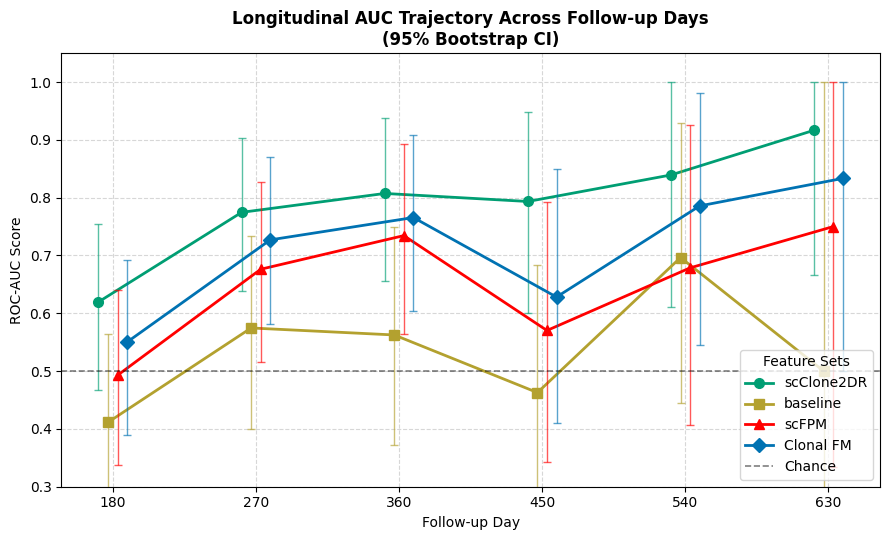

    Method  Day   AUC  CI_low  CI_high  Samples
scClone2DR  180 0.620   0.467    0.755       41
scClone2DR  270 0.775   0.638    0.904       36
scClone2DR  360 0.807   0.656    0.938       28
scClone2DR  450 0.793   0.600    0.949       22
scClone2DR  540 0.839   0.611    1.000       15
scClone2DR  630 0.917   0.667    1.000        7
  baseline  180 0.411   0.258    0.564       41
  baseline  270 0.575   0.400    0.734       36
  baseline  360 0.562   0.372    0.750       28
  baseline  450 0.463   0.248    0.683       22
  baseline  540 0.696   0.444    0.929       15
  baseline  630 0.500   0.083    1.000        7
     scFPM  180 0.493   0.338    0.640       41
     scFPM  270 0.676   0.516    0.827       36
     scFPM  360 0.734   0.564    0.892       28
     scFPM  450 0.570   0.343    0.792       22
     scFPM  540 0.679   0.407    0.926       15
     scFPM  630 0.750   0.333    1.000        7
 Clonal FM  180 0.550   0.390    0.693       41
 Clonal FM  270 0.727   0.581    0.870  

In [42]:
import matplotlib.pyplot as plt

def bootstrap_auc_ci(
    sub,
    score_col='prob_Cox_Global',
    n_boot=20000,
    alpha=0.05,
    seed=0
):
    """AUC with a percentile bootstrap CI, resampling patients."""
    sub = sub.dropna(subset=[score_col])

    y = sub['y_true'].values
    s = sub[score_col].values

    if len(np.unique(y)) < 2:
        return np.nan, np.nan, np.nan

    auc = roc_auc_score(y, s)

    # Bootstrap at patient level
    pids = sub['tupro_id'].values
    groups = {
        p: np.where(pids == p)[0]
        for p in np.unique(pids)
    }

    keys = list(groups)
    rng = np.random.default_rng(seed)

    boots = []

    for _ in range(n_boot):
        sampled_patients = rng.choice(
            keys,
            len(keys),
            replace=True
        )

        idx = np.concatenate([
            groups[p] for p in sampled_patients
        ])

        if len(np.unique(y[idx])) < 2:
            continue

        boots.append(
            roc_auc_score(y[idx], s[idx])
        )

    if len(boots) == 0:
        return auc, np.nan, np.nan

    lo, hi = np.percentile(
        boots,
        [
            100 * alpha / 2,
            100 * (1 - alpha / 2)
        ]
    )

    return auc, lo, hi


# =====================================================================
# COMPUTE AUC AND CI FOR EVERY METHOD AND DAY
# =====================================================================

ci_rows = []

for method in feature_sets.keys():
    for day in valid_days:

        sub = df_cox_results[
            (df_cox_results['method'] == method) &
            (df_cox_results['days'] == day)
        ]

        auc, lo, hi = bootstrap_auc_ci(
            sub,
            n_boot=2000,
            alpha=0.1,
            seed=0
        )

        ci_rows.append({
            'Method': method,
            'Day': day,
            'AUC': auc,
            'CI_low': lo,
            'CI_high': hi,
            'Samples': len(sub)
        })

df_auc_ci = pd.DataFrame(ci_rows)


# =====================================================================
# LONGITUDINAL AUC TRAJECTORY WITH 95% CI
# =====================================================================

fig, ax = plt.subplots(figsize=(9, 5.5))

methods = list(feature_sets.keys())

# Same markers as the previous plot
markers = {
    'scClone2DR': 'o',
    'baseline': 's',
    'scFPM': '^',
    'Clonal FM': 'D'
}

# Small horizontal shift so markers / CIs are easier to distinguish
offset_step = 6

offsets = {
    m: (i - (len(methods) - 1) / 2) * offset_step
    for i, m in enumerate(methods)
}


for method in methods:

    d = (
        df_auc_ci[
            df_auc_ci['Method'] == method
        ]
        .dropna(subset=['AUC'])
        .sort_values('Day')
    )

    x = d['Day'].values + offsets[method]

    color = colors.get(method)
    marker = markers.get(method, 'o')

    # -------------------------------------------------------------
    # 95% CI shaded region
    # -------------------------------------------------------------
    valid_ci = (
        d['CI_low'].notna() &
        d['CI_high'].notna()
    )

#     ax.fill_between(
#         x[valid_ci],
#         d.loc[valid_ci, 'CI_low'].values,
#         d.loc[valid_ci, 'CI_high'].values,
#         color=color,
#         alpha=0.12,
#         linewidth=0
#     )

    # -------------------------------------------------------------
    # AUC trajectory + method-specific marker
    # -------------------------------------------------------------
    ax.plot(
        x,
        d['AUC'].values,
        color=color,
        linewidth=2,
        marker=marker,
        markersize=7,
        markeredgewidth=1,
        label=method
    )

    # -------------------------------------------------------------
    # Optional: show CI as thin error bars
    # -------------------------------------------------------------
    ax.errorbar(
        x[valid_ci],
        d.loc[valid_ci, 'AUC'].values,
        yerr=[
            (
                d.loc[valid_ci, 'AUC'] -
                d.loc[valid_ci, 'CI_low']
            ).values,
            (
                d.loc[valid_ci, 'CI_high'] -
                d.loc[valid_ci, 'AUC']
            ).values
        ],
        fmt='none',
        ecolor=color,
        elinewidth=1,
        capsize=3,
        alpha=0.65
    )


# =====================================================================
# CHANCE LEVEL
# =====================================================================

ax.axhline(
    0.5,
    color='k',
    linestyle='--',
    linewidth=1.2,
    alpha=0.5,
    label='Chance'
)


# =====================================================================
# AXIS / LABELS
# =====================================================================

ax.set_title(
    "Longitudinal AUC Trajectory Across Follow-up Days\n"
    "(95% Bootstrap CI)",
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel("Follow-up Day")
ax.set_ylabel("ROC-AUC Score")

ax.set_ylim(0.3, 1.05)

ax.set_xticks(valid_days)
ax.set_xticklabels(valid_days)

ax.grid(
    True,
    linestyle="--",
    alpha=0.5
)

ax.legend(
    title="Feature Sets",
    loc="lower right"
)

plt.tight_layout()
plt.save
plt.show()


# =====================================================================
# PRINT RESULTS
# =====================================================================

print(
    df_auc_ci
    .round(3)
    .to_string(index=False)
)


AUC WITH 95% PATIENT-LEVEL BOOTSTRAP CI
    Method  Day   AUC  CI_low  CI_high  Samples  Patients
scClone2DR  180 0.620   0.444    0.787       41        41
scClone2DR  270 0.775   0.604    0.925       36        36
scClone2DR  360 0.807   0.622    0.952       28        28
scClone2DR  450 0.793   0.562    0.967       22        22
scClone2DR  540 0.839   0.554    1.000       15        15
scClone2DR  630 0.917   0.600    1.000        7         7
  baseline  180 0.411   0.239    0.600       41        41
  baseline  270 0.575   0.378    0.760       36        36
  baseline  360 0.562   0.338    0.776       28        28
  baseline  450 0.463   0.214    0.718       22        22
  baseline  540 0.696   0.386    0.963       15        15
  baseline  630 0.500   0.000    1.000        7         7
     scFPM  180 0.493   0.309    0.676       41        41
     scFPM  270 0.676   0.478    0.851       36        36
     scFPM  360 0.734   0.524    0.911       28        28
     scFPM  450 0.570   0.300  

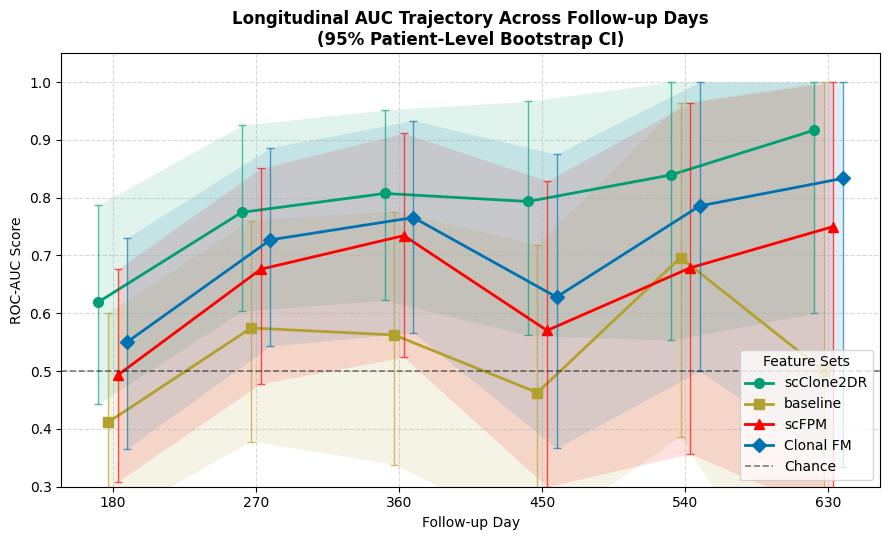

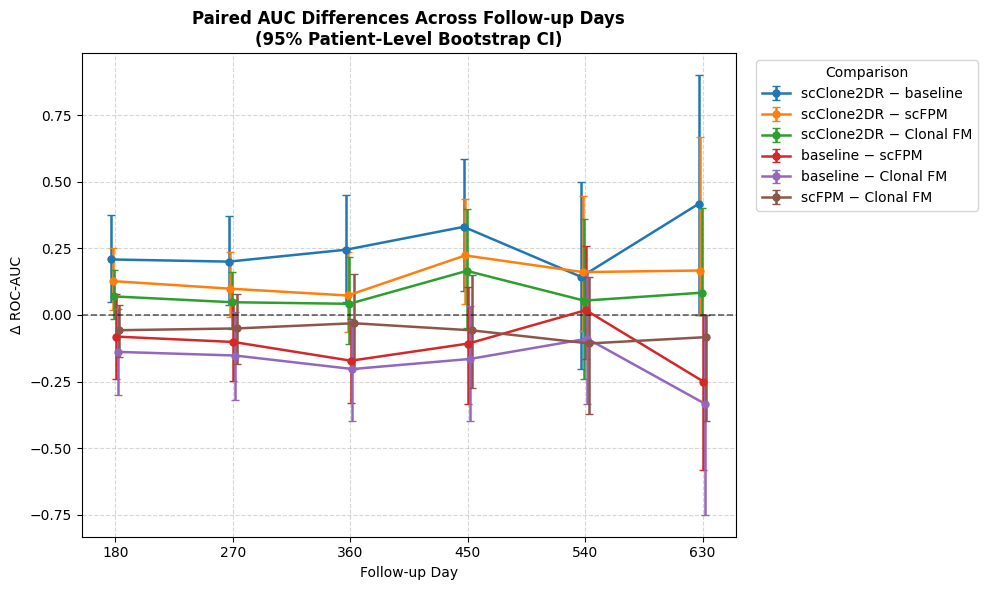


ΔAUC (METHOD A − METHOD B)
Comparison  baseline − Clonal FM  baseline − scFPM  scClone2DR − Clonal FM  scClone2DR − baseline  scClone2DR − scFPM  scFPM − Clonal FM
Day                                                                                                                                     
180                       -0.139            -0.081                   0.069                  0.208               0.127             -0.057
270                       -0.152            -0.102                   0.048                  0.200               0.098             -0.051
360                       -0.203            -0.172                   0.042                  0.245               0.073             -0.031
450                       -0.165            -0.107                   0.165                  0.331               0.223             -0.058
540                       -0.089             0.018                   0.054                  0.143               0.161             -0.107
630          

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score


# =====================================================================
# 1. PARAMETERS
# =====================================================================

# Confidence level for all bootstrap CIs
confidence_level = 95

# Number of bootstrap replicates
n_boot = 10000

# Random seed for reproducibility
seed = 0

# Feature sets / methods
methods = list(feature_sets.keys())


# =====================================================================
# 2. COLORS AND MARKERS
# =====================================================================

colors = {
    'scClone2DR': '#009E73',
    'baseline': '#B3A12F',
    'scFPM': 'red',
    'Clonal FM': '#0072B2'
}

markers = {
    'scClone2DR': 'o',
    'baseline': 's',
    'scFPM': '^',
    'Clonal FM': 'D'
}


# =====================================================================
# 3. SINGLE-METHOD PATIENT-LEVEL BOOTSTRAP CI
# =====================================================================

def bootstrap_auc_ci(
    sub,
    score_col='prob_Cox_Global',
    n_boot=10000,
    confidence_level=95,
    seed=0
):
    """
    Calculate AUC and a patient-level percentile bootstrap CI.

    All observations belonging to a patient are resampled together,
    preserving the longitudinal structure within patients.
    """

    sub = sub.dropna(subset=[score_col]).copy()

    y = sub['y_true'].values
    s = sub[score_col].values

    # Cannot calculate AUC without both classes
    if len(np.unique(y)) < 2:
        return np.nan, np.nan, np.nan

    auc = roc_auc_score(y, s)

    # -------------------------------------------------------------
    # Patient groups
    # -------------------------------------------------------------

    pids = sub['tupro_id'].values

    groups = {
        p: np.where(pids == p)[0]
        for p in np.unique(pids)
    }

    patient_ids = list(groups.keys())
    n_patients = len(patient_ids)

    rng = np.random.default_rng(seed)

    boots = []

    # -------------------------------------------------------------
    # Bootstrap
    # -------------------------------------------------------------

    for _ in range(n_boot):

        sampled_patients = rng.choice(
            patient_ids,
            size=n_patients,
            replace=True
        )

        idx = np.concatenate([
            groups[p]
            for p in sampled_patients
        ])

        y_boot = y[idx]
        s_boot = s[idx]

        # Skip bootstrap samples containing only one class
        if len(np.unique(y_boot)) < 2:
            continue

        boots.append(
            roc_auc_score(y_boot, s_boot)
        )

    if len(boots) == 0:
        return auc, np.nan, np.nan

    # -------------------------------------------------------------
    # Percentile CI
    # -------------------------------------------------------------

    alpha = 1 - confidence_level / 100

    lo, hi = np.percentile(
        boots,
        [
            100 * alpha / 2,
            100 * (1 - alpha / 2)
        ]
    )

    return auc, lo, hi


# =====================================================================
# 4. CALCULATE AUC + CI FOR EVERY METHOD AND DAY
# =====================================================================

ci_rows = []

for method in methods:

    for day in valid_days:

        sub = df_cox_results[
            (df_cox_results['method'] == method) &
            (df_cox_results['days'] == day)
        ]

        auc, lo, hi = bootstrap_auc_ci(
            sub,
            score_col='prob_Cox_Global',
            n_boot=n_boot,
            confidence_level=confidence_level,
            seed=seed
        )

        ci_rows.append({
            'Method': method,
            'Day': day,
            'AUC': auc,
            'CI_low': lo,
            'CI_high': hi,
            'Samples': len(sub),
            'Patients': sub['tupro_id'].nunique()
        })


df_auc_ci = pd.DataFrame(ci_rows)


# =====================================================================
# 5. PAIRED PATIENT-LEVEL BOOTSTRAP
# =====================================================================

def paired_bootstrap_auc_difference(
    df_results,
    method_a,
    method_b,
    day,
    score_col='prob_Cox_Global',
    n_boot=10000,
    confidence_level=95,
    seed=0
):
    """
    Paired patient-level bootstrap comparison of two methods.

    Returns:

        AUC_A
        AUC_B
        Delta_AUC = AUC_A - AUC_B
        CI_low
        CI_high
        p_value
        n_patients

    The SAME patients are sampled for method A and method B
    in every bootstrap replicate.
    """

    # -------------------------------------------------------------
    # Extract data for each method
    # -------------------------------------------------------------

    a = df_results[
        (df_results['method'] == method_a) &
        (df_results['days'] == day)
    ][['tupro_id', 'y_true', score_col]].copy()

    b = df_results[
        (df_results['method'] == method_b) &
        (df_results['days'] == day)
    ][['tupro_id', 'y_true', score_col]].copy()

    a = a.dropna(subset=[score_col])
    b = b.dropna(subset=[score_col])

    # -------------------------------------------------------------
    # Keep only patients available for BOTH methods
    # -------------------------------------------------------------

    common_patients = sorted(
        set(a['tupro_id']) &
        set(b['tupro_id'])
    )

    a = a[a['tupro_id'].isin(common_patients)].copy()
    b = b[b['tupro_id'].isin(common_patients)].copy()

    if len(common_patients) == 0:
        return {
            'Method_A': method_a,
            'Method_B': method_b,
            'Day': day,
            'AUC_A': np.nan,
            'AUC_B': np.nan,
            'Delta_AUC': np.nan,
            'CI_low': np.nan,
            'CI_high': np.nan,
            'p_value': np.nan,
            'Patients': 0
        }

    # -------------------------------------------------------------
    # Merge to ensure identical patient/sample structure
    # -------------------------------------------------------------

    # Each patient/day should normally have one row.
    # If there are multiple rows, merge them by patient and observation
    # index to preserve the longitudinal observations.

    a = a.sort_values(['tupro_id']).reset_index(drop=True)
    b = b.sort_values(['tupro_id']).reset_index(drop=True)

    # Use patient-level groups rather than relying on row alignment
    patients = common_patients

    groups_a = {
        p: a.index[a['tupro_id'] == p].to_numpy()
        for p in patients
    }

    groups_b = {
        p: b.index[b['tupro_id'] == p].to_numpy()
        for p in patients
    }

    # -------------------------------------------------------------
    # Observed AUCs
    # -------------------------------------------------------------

    y_a = a['y_true'].values
    s_a = a[score_col].values

    y_b = b['y_true'].values
    s_b = b[score_col].values

    if len(np.unique(y_a)) < 2 or len(np.unique(y_b)) < 2:
        return {
            'Method_A': method_a,
            'Method_B': method_b,
            'Day': day,
            'AUC_A': np.nan,
            'AUC_B': np.nan,
            'Delta_AUC': np.nan,
            'CI_low': np.nan,
            'CI_high': np.nan,
            'p_value': np.nan,
            'Patients': len(patients)
        }

    auc_a = roc_auc_score(y_a, s_a)
    auc_b = roc_auc_score(y_b, s_b)

    observed_delta = auc_a - auc_b

    # -------------------------------------------------------------
    # Bootstrap
    # -------------------------------------------------------------

    rng = np.random.default_rng(seed)

    boot_deltas = []

    n_patients = len(patients)

    for _ in range(n_boot):

        # IMPORTANT:
        # Same patient sample for A and B
        sampled_patients = rng.choice(
            patients,
            size=n_patients,
            replace=True
        )

        idx_a = np.concatenate([
            groups_a[p]
            for p in sampled_patients
        ])

        idx_b = np.concatenate([
            groups_b[p]
            for p in sampled_patients
        ])

        y_a_boot = y_a[idx_a]
        s_a_boot = s_a[idx_a]

        y_b_boot = y_b[idx_b]
        s_b_boot = s_b[idx_b]

        # Both methods must have both classes
        if (
            len(np.unique(y_a_boot)) < 2 or
            len(np.unique(y_b_boot)) < 2
        ):
            continue

        auc_a_boot = roc_auc_score(
            y_a_boot,
            s_a_boot
        )

        auc_b_boot = roc_auc_score(
            y_b_boot,
            s_b_boot
        )

        boot_deltas.append(
            auc_a_boot - auc_b_boot
        )

    if len(boot_deltas) == 0:
        return {
            'Method_A': method_a,
            'Method_B': method_b,
            'Day': day,
            'AUC_A': auc_a,
            'AUC_B': auc_b,
            'Delta_AUC': observed_delta,
            'CI_low': np.nan,
            'CI_high': np.nan,
            'p_value': np.nan,
            'Patients': n_patients
        }

    boot_deltas = np.asarray(boot_deltas)

    # -------------------------------------------------------------
    # Confidence interval
    # -------------------------------------------------------------

    alpha = 1 - confidence_level / 100

    ci_low, ci_high = np.percentile(
        boot_deltas,
        [
            100 * alpha / 2,
            100 * (1 - alpha / 2)
        ]
    )

    # -------------------------------------------------------------
    # Two-sided bootstrap p-value
    #
    # Null hypothesis: Delta AUC = 0
    # -------------------------------------------------------------

    p_lower = np.mean(
        boot_deltas <= 0
    )

    p_upper = np.mean(
        boot_deltas >= 0
    )

    p_value = 2 * min(
        p_lower,
        p_upper
    )

    p_value = min(
        p_value,
        1.0
    )

    return {
        'Method_A': method_a,
        'Method_B': method_b,
        'Day': day,
        'AUC_A': auc_a,
        'AUC_B': auc_b,
        'Delta_AUC': observed_delta,
        'CI_low': ci_low,
        'CI_high': ci_high,
        'p_value': p_value,
        'Patients': n_patients
    }


# =====================================================================
# 6. RUN ALL PAIRWISE COMPARISONS
# =====================================================================

from itertools import combinations

comparison_rows = []

for day in valid_days:

    for method_a, method_b in combinations(methods, 2):

        result = paired_bootstrap_auc_difference(
            df_cox_results,
            method_a=method_a,
            method_b=method_b,
            day=day,
            score_col='prob_Cox_Global',
            n_boot=n_boot,
            confidence_level=confidence_level,
            seed=seed
        )

        comparison_rows.append(result)


df_auc_comparison = pd.DataFrame(
    comparison_rows
)


# =====================================================================
# 7. DISPLAY AUC + CI
# =====================================================================

print("\n" + "=" * 90)
print(
    f"AUC WITH {confidence_level}% PATIENT-LEVEL BOOTSTRAP CI"
)
print("=" * 90)

print(
    df_auc_ci.round(3).to_string(index=False)
)


# =====================================================================
# 8. DISPLAY PAIRED AUC DIFFERENCES
# =====================================================================

print("\n" + "=" * 90)
print(
    f"PAIRED AUC DIFFERENCES "
    f"({confidence_level}% PATIENT-LEVEL BOOTSTRAP CI)"
)
print("=" * 90)

display_cols = [
    'Method_A',
    'Method_B',
    'Day',
    'AUC_A',
    'AUC_B',
    'Delta_AUC',
    'CI_low',
    'CI_high',
    'p_value',
    'Patients'
]

print(
    df_auc_comparison[
        display_cols
    ].round(3).to_string(index=False)
)


# =====================================================================
# 9. LONGITUDINAL AUC PLOT WITH CI
# =====================================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

offset_step = 6

offsets = {
    m: (
        i - (len(methods) - 1) / 2
    ) * offset_step
    for i, m in enumerate(methods)
}


for method in methods:

    d = (
        df_auc_ci[
            df_auc_ci['Method'] == method
        ]
        .dropna(subset=['AUC'])
        .sort_values('Day')
    )

    x = (
        d['Day'].values +
        offsets[method]
    )

    color = colors.get(method)
    marker = markers.get(method, 'o')

    valid_ci = (
        d['CI_low'].notna() &
        d['CI_high'].notna()
    )

    # CI band
    ax.fill_between(
        x[valid_ci],
        d.loc[
            valid_ci, 'CI_low'
        ].values,
        d.loc[
            valid_ci, 'CI_high'
        ].values,
        color=color,
        alpha=0.12,
        linewidth=0
    )

    # AUC line + method-specific marker
    ax.plot(
        x,
        d['AUC'].values,
        color=color,
        linewidth=2,
        marker=marker,
        markersize=7,
        markeredgewidth=1,
        label=method
    )

    # CI error bars
    ax.errorbar(
        x[valid_ci],
        d.loc[
            valid_ci, 'AUC'
        ].values,
        yerr=[
            (
                d.loc[
                    valid_ci, 'AUC'
                ] -
                d.loc[
                    valid_ci, 'CI_low'
                ]
            ).values,

            (
                d.loc[
                    valid_ci, 'CI_high'
                ] -
                d.loc[
                    valid_ci, 'AUC'
                ]
            ).values
        ],
        fmt='none',
        ecolor=color,
        elinewidth=1,
        capsize=3,
        alpha=0.65
    )


ax.axhline(
    0.5,
    color='k',
    linestyle='--',
    linewidth=1.2,
    alpha=0.5,
    label='Chance'
)

ax.set_title(
    f"Longitudinal AUC Trajectory Across Follow-up Days\n"
    f"({confidence_level}% Patient-Level Bootstrap CI)",
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel("Follow-up Day")
ax.set_ylabel("ROC-AUC Score")

ax.set_ylim(
    0.3,
    1.05
)

ax.set_xticks(
    valid_days
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.5
)

ax.legend(
    title="Feature Sets",
    loc="lower right"
)

plt.tight_layout()
plt.show()


# =====================================================================
# 10. PAIRED ΔAUC PLOT
# =====================================================================

# Create a label for each pair
df_auc_comparison['Comparison'] = (
    df_auc_comparison['Method_A']
    + " − "
    + df_auc_comparison['Method_B']
)


comparisons = (
    df_auc_comparison['Comparison']
    .unique()
)


# Plot each pair separately
fig, ax = plt.subplots(
    figsize=(10, 6)
)

pair_offsets = np.linspace(
    -3,
    3,
    len(comparisons)
)

for offset, comparison in zip(
    pair_offsets,
    comparisons
):

    d = (
        df_auc_comparison[
            df_auc_comparison['Comparison'] ==
            comparison
        ]
        .dropna(subset=['Delta_AUC'])
        .sort_values('Day')
    )

    if len(d) == 0:
        continue

    x = (
        d['Day'].values +
        offset
    )

    ax.errorbar(
        x,
        d['Delta_AUC'].values,

        yerr=[
            (
                d['Delta_AUC'] -
                d['CI_low']
            ).values,

            (
                d['CI_high'] -
                d['Delta_AUC']
            ).values
        ],

        fmt='o-',
        linewidth=1.8,
        markersize=5,
        capsize=3,
        label=comparison
    )


# Zero = no difference between methods
ax.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1.2,
    alpha=0.6
)

ax.set_title(
    f"Paired AUC Differences Across Follow-up Days\n"
    f"({confidence_level}% Patient-Level Bootstrap CI)",
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel("Follow-up Day")
ax.set_ylabel("Δ ROC-AUC")

ax.set_xticks(
    valid_days
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.5
)

ax.legend(
    title="Comparison",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


# =====================================================================
# 11. OPTIONAL: PIVOT TABLE OF ΔAUC
# =====================================================================

delta_pivot = df_auc_comparison.pivot(
    index='Day',
    columns='Comparison',
    values='Delta_AUC'
)

print("\n" + "=" * 90)
print("ΔAUC (METHOD A − METHOD B)")
print("=" * 90)

print(
    delta_pivot.round(3).to_string()
)


# =====================================================================
# 12. OPTIONAL: PIVOT TABLE OF P-VALUES
# =====================================================================

pvalue_pivot = df_auc_comparison.pivot(
    index='Day',
    columns='Comparison',
    values='p_value'
)

print("\n" + "=" * 90)
print("BOOTSTRAP P-VALUES")
print("=" * 90)

print(
    pvalue_pivot.round(3).to_string()
)

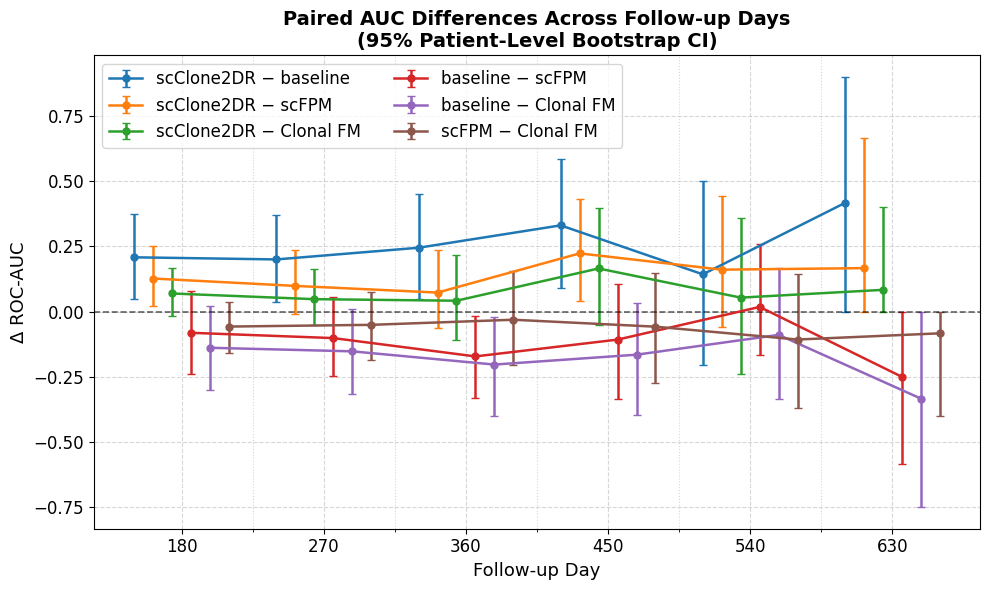

In [56]:

# Plot each pair separately
fig, ax = plt.subplots(
    figsize=(10, 6)
)

pair_offsets = np.linspace(
    -30,
    30,
    len(comparisons)
)

for offset, comparison in zip(
    pair_offsets,
    comparisons
):

    d = (
        df_auc_comparison[
            df_auc_comparison['Comparison'] ==
            comparison
        ]
        .dropna(subset=['Delta_AUC'])
        .sort_values('Day')
    )

    if len(d) == 0:
        continue

    x = (
        d['Day'].values +
        offset
    )

    ax.errorbar(
        x,
        d['Delta_AUC'].values,

        yerr=[
            (
                d['Delta_AUC'] -
                d['CI_low']
            ).values,

            (
                d['CI_high'] -
                d['Delta_AUC']
            ).values
        ],

        fmt='o-',
        linewidth=1.8,
        markersize=5,
        capsize=3,
        label=comparison
    )


# Zero = no difference between methods
ax.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1.2,
    alpha=0.6
)

ax.set_title(
    f"Paired AUC Differences Across Follow-up Days\n"
    f"({confidence_level}% Patient-Level Bootstrap CI)",
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel("Follow-up Day", fontsize=13)
ax.set_ylabel("Δ ROC-AUC", fontsize=13)

ax.set_xticks(
    valid_days
)

# Add minor x-ticks between the follow-up days
ax.set_xticks(
    valid_days,
    minor=False
)

# Minor ticks halfway between consecutive major ticks
minor_x = (
    (np.array(valid_days[:-1]) + np.array(valid_days[1:])) / 2
)

ax.set_xticks(
    minor_x,
    minor=True
)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=12
)

# Major grid
ax.grid(
    True,
    which="major",
    axis="both",
    linestyle="--",
    alpha=0.5
)

# Minor vertical grid between x-ticks
ax.grid(
    True,
    which="minor",
    axis="x",
    linestyle=":",
    alpha=0.5
)

ax.legend(
    loc='upper left',
    ncol=2,
    fontsize=12
)

plt.tight_layout()
plt.savefig('cox_paired_AUC.png', dpi=400, bbox_inches='tight')
plt.show()

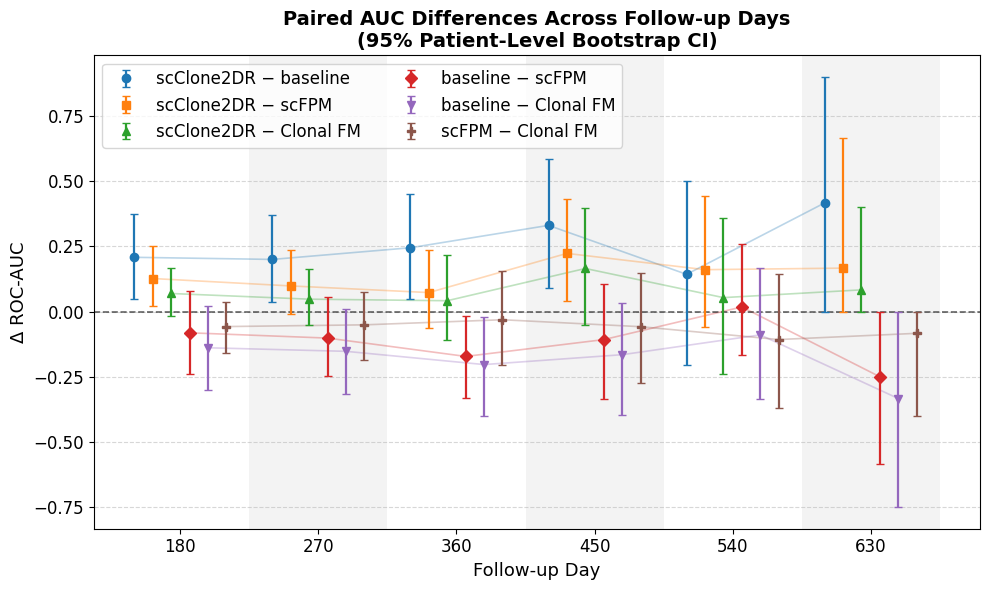

In [66]:
# Plot each pair separately
fig, ax = plt.subplots(
    figsize=(10, 6)
)

pair_offsets = np.linspace(
    -30,
    30,
    len(comparisons)
)

# ---------------------------------------------------------
# Alternating background for each follow-up interval
# ---------------------------------------------------------
valid_days = np.array(valid_days)

# Extend the first/last interval by half the distance
# to the neighbouring follow-up
half_widths = np.diff(valid_days) / 2

left_boundary = (
    valid_days[0] - half_widths[0]
)

right_boundary = (
    valid_days[-1] + half_widths[-1]
)

# Vertical boundaries between follow-ups
boundaries = (
    (valid_days[:-1] + valid_days[1:]) / 2
)

# All boundaries
interval_edges = np.concatenate([
    [left_boundary],
    boundaries,
    [right_boundary]
])

# Alternate white / light-gray intervals
for i in range(len(interval_edges) - 1):

    if i % 2 == 1:
        ax.axvspan(
            interval_edges[i],
            interval_edges[i + 1],
            facecolor='lightgray',
            alpha=0.25,
            zorder=0
        )


# ---------------------------------------------------------
# Plot each comparison
# ---------------------------------------------------------
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<', '>']

for idx, (offset, comparison) in enumerate(
    zip(pair_offsets, comparisons)
):

    d = (
        df_auc_comparison[
            df_auc_comparison['Comparison'] ==
            comparison
        ]
        .dropna(subset=['Delta_AUC'])
        .sort_values('Day')
    )

    if len(d) == 0:
        continue

    x = d['Day'].values + offset
    marker = markers[idx % len(markers)]

    # Transparent connecting line
    line_obj, = ax.plot(
        x,
        d['Delta_AUC'].values,
        linestyle='-',
        linewidth=1.2,
        alpha=0.3,
        zorder=2
    )

    color = line_obj.get_color()

    # Full-opacity markers + error bars (no connecting line)
    ax.errorbar(
        x,
        d['Delta_AUC'].values,

        yerr=[
            (d['Delta_AUC'] - d['CI_low']).values,
            (d['CI_high'] - d['Delta_AUC']).values
        ],

        fmt=marker,
        color=color,
        ecolor=color,
        linewidth=1.6,
        markersize=6,
        capsize=3,
        label=comparison,
        zorder=3
    )


# ---------------------------------------------------------
# Zero = no difference between methods
# ---------------------------------------------------------
ax.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1.2,
    alpha=0.6,
    zorder=2
)


# ---------------------------------------------------------
# Labels
# ---------------------------------------------------------
ax.set_title(
    f"Paired AUC Differences Across Follow-up Days\n"
    f"({confidence_level}% Patient-Level Bootstrap CI)",
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel(
    "Follow-up Day",
    fontsize=13
)

ax.set_ylabel(
    "Δ ROC-AUC",
    fontsize=13
)


# ---------------------------------------------------------
# X-axis
# ---------------------------------------------------------
ax.set_xticks(
    valid_days
)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=12
)


# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------
# Only horizontal grid lines.
# No vertical grid lines on the follow-up ticks.
ax.grid(
    True,
    which='major',
    axis='y',
    linestyle='--',
    alpha=0.5,
    zorder=1
)


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------
ax.legend(
    loc='upper left',
    ncol=2,
    fontsize=12
)


plt.tight_layout()

plt.savefig(
    'cox_paired_AUC.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()